# Notebook 03: Data Cleaning and Preprocessing

## Objective

The goal of this notebook is to clean and prepare the combined HUPA-UCM Diabetes Dataset for future descriptive, prescriptive, and limited predictive analysis.

In Notebook 02, the patient CSV files were loaded, combined, and basic structure checks were completed. In this notebook, we will:

- Load the combined processed dataset
- Verify data types
- Check missing values again
- Check duplicates
- Validate time-series consistency
- Detect and review outliers
- Create glucose risk categories
- Engineer useful time-series features
- Save a clean analysis-ready dataset

This cleaned dataset will be used in later notebooks for exploratory analysis, modeling, and the Streamlit dashboard.

## 1. Import Required Libraries

We first import the Python libraries needed for data cleaning, preprocessing, and visualization.

Why this step is important:
- pandas helps us work with tabular data
- numpy helps with numerical calculations
- matplotlib and seaborn help us visualize distributions and outliers
- os helps us manage file paths

Consequence if skipped:
- The notebook will not be able to load, clean, or visualize the dataset.

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

## 2. Define Project Paths

We define reusable folder paths so the notebook works consistently within the project structure.

Why this step is important:
- Avoids hardcoding file paths repeatedly
- Makes the project easier to maintain
- Helps avoid FileNotFoundError issues

Consequence if skipped:
- File loading and saving may become messy and error-prone.

In [2]:
DATA_DIR = "../data/processed"
OUTPUT_DIR = "../outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

combined_file_path = os.path.join(DATA_DIR, "combined_raw_patient_data.csv")

print("Combined file path:", combined_file_path)
print("File exists:", os.path.exists(combined_file_path))

Combined file path: ../data/processed\combined_raw_patient_data.csv
File exists: True


## 3. Load the Combined Dataset

We load the combined dataset created in Notebook 02.

Important note:
The original patient CSV files used a semicolon separator. However, this combined file was already saved as a processed CSV, so we load it normally unless it was also saved with semicolon formatting.

Why this step is important:
- This gives us one complete dataset for cleaning and preprocessing

Consequence if skipped:
- We cannot continue with cleaning or analysis.

In [3]:
df = pd.read_csv(combined_file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (309392, 9)


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
0,2018-06-13T18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P
1,2018-06-13T18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P
2,2018-06-13T18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P
3,2018-06-13T18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P
4,2018-06-13T19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P


## 4. Inspect Dataset Structure

We review the dataset shape, columns, and data types.

Why this step is important:
- Confirms that all expected columns are present
- Helps identify incorrect data types
- Ensures the dataset loaded properly

Consequence if skipped:
- Errors may appear later during time-based analysis, feature engineering, or modeling.

In [4]:
print("Rows and columns:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
df.info()

Rows and columns: (309392, 9)

Columns:
['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'patient_id']

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 309392 entries, 0 to 309391
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time                    309392 non-null  str    
 1   glucose                 309392 non-null  float64
 2   calories                309392 non-null  float64
 3   heart_rate              309392 non-null  float64
 4   steps                   309392 non-null  float64
 5   basal_rate              309392 non-null  float64
 6   bolus_volume_delivered  309392 non-null  float64
 7   carb_input              309392 non-null  float64
 8   patient_id              309392 non-null  str    
dtypes: float64(7), str(2)
memory usage: 29.5 MB


## 5. Convert Time Column to Datetime

Even though the time column was converted in Notebook 02, CSV files do not always preserve datetime types after saving. Therefore, we convert it again after loading.

Why this step is important:
- Allows time-based sorting
- Enables creation of time features
- Supports time-series validation

Consequence if skipped:
- Time-based operations may fail or give incorrect results.

In [5]:
df["time"] = pd.to_datetime(df["time"], errors="coerce")

print(df["time"].dtype)
df[["patient_id", "time"]].head()

datetime64[us]


,patient_id,time
0,HUPA0001P,2018-06-13 18:40:00
1,HUPA0001P,2018-06-13 18:45:00
2,HUPA0001P,2018-06-13 18:50:00
3,HUPA0001P,2018-06-13 18:55:00
4,HUPA0001P,2018-06-13 19:00:00


## 6. Sort Dataset by Patient and Time

We sort the data by patient_id and time to preserve the correct time-series order.

Why this step is important:
- Lag features depend on correct chronological order
- Rolling features require proper time order
- Patient-level trends become more reliable

Consequence if skipped:
- Lag and rolling features may be calculated incorrectly.

In [6]:
df = df.sort_values(by=["patient_id", "time"]).reset_index(drop=True)

df[["patient_id", "time", "glucose"]].head()

,patient_id,time,glucose
0,HUPA0001P,2018-06-13 18:40:00,332.0
1,HUPA0001P,2018-06-13 18:45:00,326.0
2,HUPA0001P,2018-06-13 18:50:00,330.0
3,HUPA0001P,2018-06-13 18:55:00,324.0
4,HUPA0001P,2018-06-13 19:00:00,306.0


## 7. Check Missing Values

We check whether any columns contain missing values.

Why this step is important:
- Missing values can affect descriptive analysis
- Machine learning models may fail if missing values are not handled
- Missing values in glucose or time columns can distort conclusions

Consequence if skipped:
- Later analysis may produce incorrect results or errors.

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().sum() / len(df)) * 100
})

missing_summary.sort_values(by="missing_count", ascending=False)

,missing_count,missing_percentage
time,0,0.0
glucose,0,0.0
calories,0,0.0
heart_rate,0,0.0
steps,0,0.0
basal_rate,0,0.0
bolus_volume_delivered,0,0.0
carb_input,0,0.0
patient_id,0,0.0


In [8]:
missing_nonzero = missing_summary[missing_summary["missing_count"] > 0]

if missing_nonzero.empty:
    print("No missing values found. Missing value visualization is not needed.")
else:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=missing_nonzero.reset_index(),
        x="missing_percentage",
        y="index"
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Missing Percentage")
    plt.ylabel("Column")
    plt.show()

No missing values found. Missing value visualization is not needed.


## 8. Handle Missing Values

Since no missing values were found, no imputation is required.

Why this step is important:
- Confirms that the dataset is complete
- Documents the decision not to modify the data

Consequence if skipped:
- Readers may not know whether missing values were reviewed.

In [9]:
if df.isna().sum().sum() == 0:
    print("No missing values found. No missing value treatment required.")
else:
    print("Missing values found. Review required.")

No missing values found. No missing value treatment required.


## 9. Check for Duplicate Rows

We check whether the dataset contains duplicate records.

Why this step is important:
- Duplicate rows can overrepresent certain patients or time periods
- They can distort averages, trends, and model training

Consequence if skipped:
- Analysis may become biased because repeated records are counted multiple times.

In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [11]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
    print("New shape:", df.shape)
else:
    print("No duplicate rows found.")

No duplicate rows found.


## 10. Check Duplicate Patient-Time Records

For time-series data, each patient should ideally have one record per timestamp. We check for duplicate patient_id and time combinations.

Why this step is important:
- Duplicate timestamps for the same patient can affect time-series analysis
- Lag and rolling calculations may become unreliable

Consequence if skipped:
- Patient trends and time-based features may be incorrect.

In [12]:
duplicate_patient_time = df.duplicated(subset=["patient_id", "time"]).sum()

print("Duplicate patient-time records:", duplicate_patient_time)

Duplicate patient-time records: 0


In [13]:
if duplicate_patient_time > 0:
    df = df.drop_duplicates(subset=["patient_id", "time"]).reset_index(drop=True)
    print("Duplicate patient-time records removed.")
    print("New shape:", df.shape)
else:
    print("No duplicate patient-time records found.")

No duplicate patient-time records found.


## 11. Validate Time-Series Gaps

The dataset is expected to have regular time intervals, often around 5 minutes. We calculate the time difference between consecutive records for each patient.

Why this step is important:
- Identifies irregular gaps in patient data
- Helps determine whether rolling features are reliable
- Supports transparency in time-series analysis

Consequence if skipped:
- We may assume the data is evenly spaced when it is not.

In [14]:
df["time_diff"] = df.groupby("patient_id")["time"].diff()

time_gap_summary = df["time_diff"].value_counts().head(10)

time_gap_summary

time_diff
0 days 00:05:00    309367
Name: count, dtype: int64

In [15]:
print("Most common time gaps:")
print(df["time_diff"].value_counts().head(10))

Most common time gaps:
time_diff
0 days 00:05:00    309367
Name: count, dtype: int64


## 12. Review Numeric Summary Statistics

We review summary statistics for key numerical variables.

Why this step is important:
- Helps identify unusual minimum or maximum values
- Provides an overview of glucose, activity, insulin, and nutrition variables
- Supports outlier detection

Consequence if skipped:
- Extreme or unrealistic values may go unnoticed.

In [16]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
glucose,309392.0,141.425051,57.085587,40.000000,99.666667,132.000000,173.000000,444.000000
calories,309392.0,8.813568,6.930449,0.000000,5.846100,6.278100,9.193060,106.350000
heart_rate,309392.0,76.990001,15.546699,32.407773,64.930233,75.418726,85.612685,195.615385
steps,309392.0,30.825005,84.981109,0.000000,0.000000,0.000000,11.000000,842.000000
basal_rate,309392.0,0.041324,0.036106,0.000000,0.000000,0.056000,0.066000,0.250000
bolus_volume_delivered,309392.0,0.066058,0.755075,-3.000000,0.000000,0.000000,0.000000,19.800000
carb_input,309392.0,0.052718,1.505433,0.000000,0.000000,0.000000,0.000000,130.000000


## 13. Review Glucose Outliers

We inspect glucose values to identify unusually low or high readings.

Why this step is important:
- Glucose is the main target variable in this project
- Extreme glucose values may represent real medical events or sensor noise
- We should review them before removing anything

Consequence if skipped:
- Important high-risk or low-risk events may be misunderstood.

In [17]:
df["glucose"].describe()

count    309392.000000
mean        141.425051
std          57.085587
min          40.000000
25%          99.666667
50%         132.000000
75%         173.000000
max         444.000000
Name: glucose, dtype: float64

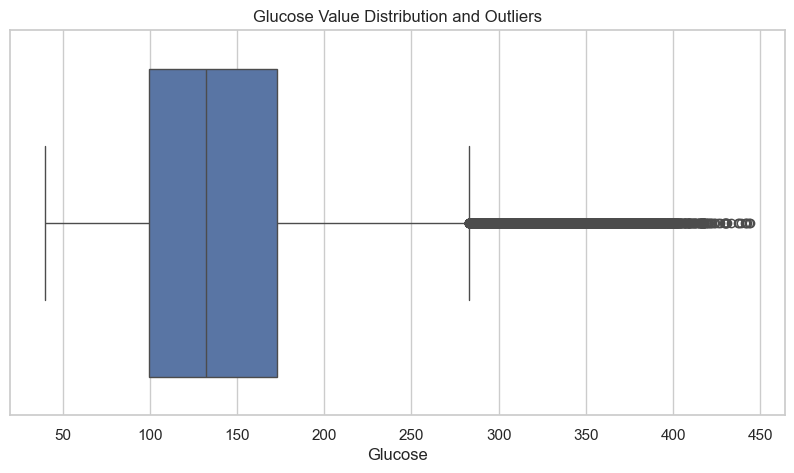

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="glucose")
plt.title("Glucose Value Distribution and Outliers")
plt.xlabel("Glucose")
plt.show()

## 14. Flag Extreme Glucose Values

Instead of removing glucose outliers immediately, we create a flag for extreme values. In healthcare-related data, extreme values may be clinically meaningful.

Why this step is important:
- Preserves potentially important medical events
- Allows future analysis of extreme glucose behavior
- Avoids deleting meaningful patient records too early

Consequence if skipped:
- We may either ignore extreme events or remove important health-related signals.

In [19]:
low_glucose_threshold = 70
high_glucose_threshold = 180

df["is_low_glucose"] = df["glucose"] < low_glucose_threshold
df["is_high_glucose"] = df["glucose"] > high_glucose_threshold

df[["glucose", "is_low_glucose", "is_high_glucose"]].head()

,glucose,is_low_glucose,is_high_glucose
0,332.0,False,True
1,326.0,False,True
2,330.0,False,True
3,324.0,False,True
4,306.0,False,True


In [20]:
print("Low glucose records:", df["is_low_glucose"].sum())
print("High glucose records:", df["is_high_glucose"].sum())

Low glucose records: 20377
High glucose records: 67123


## 15. Create Glucose Risk Categories

We categorize glucose readings into clinically meaningful groups:

- Low: glucose below 70
- Normal: glucose between 70 and 180
- High: glucose above 180

Why this step is important:
- Makes descriptive analysis easier
- Supports dashboard filtering
- Helps communicate glucose risk patterns clearly

Consequence if skipped:
- Analysis will rely only on raw glucose values, which may be harder to interpret.

In [21]:
def categorize_glucose(value):
    if value < 70:
        return "Low"
    elif value <= 180:
        return "Normal"
    else:
        return "High"

df["glucose_category"] = df["glucose"].apply(categorize_glucose)

df["glucose_category"].value_counts()

glucose_category
Normal    221892
High       67123
Low        20377
Name: count, dtype: int64

## 16. Create Time-Based Features

We create time features from the datetime column.

Features created:
- hour
- day
- day_of_week
- date
- month

Why this step is important:
- Supports analysis by time of day
- Helps identify daily glucose patterns
- Useful for dashboard filters and trend charts

Consequence if skipped:
- We cannot easily analyze glucose patterns across time periods.

In [22]:
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["day_of_week"] = df["time"].dt.day_name()
df["date"] = df["time"].dt.date
df["month"] = df["time"].dt.month

df[["time", "hour", "day", "day_of_week", "date", "month"]].head()

,time,hour,day,day_of_week,date,month
0,2018-06-13 18:40:00,18,13,Wednesday,2018-06-13,6
1,2018-06-13 18:45:00,18,13,Wednesday,2018-06-13,6
2,2018-06-13 18:50:00,18,13,Wednesday,2018-06-13,6
3,2018-06-13 18:55:00,18,13,Wednesday,2018-06-13,6
4,2018-06-13 19:00:00,19,13,Wednesday,2018-06-13,6


## 17. Create Glucose Lag Features

Lag features capture previous glucose values for each patient.

We create:
- glucose_lag_1: previous reading
- glucose_lag_3: reading from 3 intervals before
- glucose_lag_6: reading from 6 intervals before

Why this step is important:
- Glucose is time-dependent
- Previous glucose readings help explain current glucose levels
- Useful for limited predictive modeling later

Consequence if skipped:
- Predictive analysis may lose important time-series information.

In [23]:
df["glucose_lag_1"] = df.groupby("patient_id")["glucose"].shift(1)
df["glucose_lag_3"] = df.groupby("patient_id")["glucose"].shift(3)
df["glucose_lag_6"] = df.groupby("patient_id")["glucose"].shift(6)

df[["patient_id", "time", "glucose", "glucose_lag_1", "glucose_lag_3", "glucose_lag_6"]].head(10)

,patient_id,time,glucose,glucose_lag_1,glucose_lag_3,glucose_lag_6
0,HUPA0001P,2018-06-13 18:40:00,332.0,NaN,NaN,NaN
1,HUPA0001P,2018-06-13 18:45:00,326.0,332.0,NaN,NaN
2,HUPA0001P,2018-06-13 18:50:00,330.0,326.0,NaN,NaN
3,HUPA0001P,2018-06-13 18:55:00,324.0,330.0,332.0,NaN
4,HUPA0001P,2018-06-13 19:00:00,306.0,324.0,326.0,NaN
5,HUPA0001P,2018-06-13 19:05:00,313.0,306.0,330.0,NaN
6,HUPA0001P,2018-06-13 19:10:00,312.0,313.0,324.0,332.0
7,HUPA0001P,2018-06-13 19:15:00,293.0,312.0,306.0,326.0
8,HUPA0001P,2018-06-13 19:20:00,303.0,293.0,313.0,330.0
9,HUPA0001P,2018-06-13 19:25:00,293.0,303.0,312.0,324.0


## 18. Create Rolling Glucose Features

Rolling features calculate recent average glucose levels for each patient.

We create:
- glucose_rolling_30min
- glucose_rolling_1hr

Assuming 5-minute intervals:
- 30 minutes = 6 readings
- 1 hour = 12 readings

Why this step is important:
- Smooths short-term glucose fluctuations
- Captures recent glucose trends
- Useful for descriptive and predictive analysis

Consequence if skipped:
- We may miss short-term glucose patterns and trends.

In [24]:
df["glucose_rolling_30min"] = (
    df.groupby("patient_id")["glucose"]
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

df["glucose_rolling_1hr"] = (
    df.groupby("patient_id")["glucose"]
    .transform(lambda x: x.rolling(window=12, min_periods=1).mean())
)

df[["patient_id", "time", "glucose", "glucose_rolling_30min", "glucose_rolling_1hr"]].head(10)

,patient_id,time,glucose,glucose_rolling_30min,glucose_rolling_1hr
0,HUPA0001P,2018-06-13 18:40:00,332.0,332.000000,332.000000
1,HUPA0001P,2018-06-13 18:45:00,326.0,329.000000,329.000000
2,HUPA0001P,2018-06-13 18:50:00,330.0,329.333333,329.333333
3,HUPA0001P,2018-06-13 18:55:00,324.0,328.000000,328.000000
4,HUPA0001P,2018-06-13 19:00:00,306.0,323.600000,323.600000
5,HUPA0001P,2018-06-13 19:05:00,313.0,321.833333,321.833333
6,HUPA0001P,2018-06-13 19:10:00,312.0,318.500000,320.428571
7,HUPA0001P,2018-06-13 19:15:00,293.0,313.000000,317.000000
8,HUPA0001P,2018-06-13 19:20:00,303.0,308.500000,315.444444
9,HUPA0001P,2018-06-13 19:25:00,293.0,303.333333,313.200000


## 19. Review Missing Values Created by Lag Features

Lag features naturally create missing values at the beginning of each patient's time series because there is no previous reading available.

Why this step is important:
- These missing values are expected
- We need to decide how to handle them before modeling

Consequence if skipped:
- Later modeling steps may fail due to NaN values.

In [25]:
lag_missing = df[["glucose_lag_1", "glucose_lag_3", "glucose_lag_6"]].isna().sum()

lag_missing

glucose_lag_1     25
glucose_lag_3     75
glucose_lag_6    150
dtype: int64

In [26]:
print("Lag feature missing values are expected and will be handled before modeling.")

Lag feature missing values are expected and will be handled before modeling.


## 20. Create Patient-Level Summary Dataset

We create a summary table at the patient level.

Why this step is important:
- Useful for patient-level descriptive analysis
- Supports dashboard summary cards
- Helps compare glucose behavior across patients

Consequence if skipped:
- We will need to recalculate patient-level metrics repeatedly later.

In [27]:
patient_summary = df.groupby("patient_id").agg(
    start_time=("time", "min"),
    end_time=("time", "max"),
    total_records=("time", "count"),
    avg_glucose=("glucose", "mean"),
    min_glucose=("glucose", "min"),
    max_glucose=("glucose", "max"),
    low_glucose_events=("is_low_glucose", "sum"),
    high_glucose_events=("is_high_glucose", "sum")
).reset_index()

patient_summary.head()

,patient_id,start_time,end_time,total_records,avg_glucose,min_glucose,max_glucose,low_glucose_events,high_glucose_events
0,HUPA0001P,2018-06-13 18:40:00,2018-06-27 23:55:00,4096,181.443726,40.0,444.0,59,1723
1,HUPA0002P,2018-06-13 22:45:00,2018-06-24 23:45:00,3181,113.469664,40.0,310.0,759,466
2,HUPA0003P,2018-06-13 21:40:00,2018-06-26 23:45:00,3770,143.273519,44.0,366.0,265,954
3,HUPA0004P,2018-07-09 15:30:00,2018-07-20 16:45:00,3184,180.377984,40.0,411.0,309,1448
4,HUPA0005P,2018-07-09 14:20:00,2018-07-22 23:45:00,3858,147.698624,40.0,379.0,114,973


## 21. Save Cleaned and Preprocessed Datasets

We save two processed files:

1. Cleaned full dataset
2. Patient-level summary dataset

Why this step is important:
- Later notebooks can load clean data directly
- Avoids repeating preprocessing steps
- Keeps the project organized and reproducible

Consequence if skipped:
- Future notebooks may require repeated cleaning work.

In [28]:
cleaned_data_path = os.path.join(DATA_DIR, "glucovision_cleaned_preprocessed.csv")
patient_summary_path = os.path.join(DATA_DIR, "patient_summary.csv")

df.to_csv(cleaned_data_path, index=False)
patient_summary.to_csv(patient_summary_path, index=False)

print("Cleaned dataset saved to:", cleaned_data_path)
print("Patient summary saved to:", patient_summary_path)

Cleaned dataset saved to: ../data/processed\glucovision_cleaned_preprocessed.csv
Patient summary saved to: ../data/processed\patient_summary.csv


## 22. Final Validation

Before ending the notebook, we confirm that the cleaned files were saved successfully and review the final dataset shape.

Why this step is important:
- Confirms that preprocessing completed successfully
- Ensures output files are available for the next notebook

Consequence if skipped:
- We may move forward without confirming that the processed files exist.

In [29]:
print("Final cleaned dataset shape:", df.shape)
print("Patient summary shape:", patient_summary.shape)

print("\nFiles in processed folder:")
print(os.listdir(DATA_DIR))

Final cleaned dataset shape: (309392, 23)
Patient summary shape: (25, 9)

Files in processed folder:
['combined_raw_patient_data.csv', 'data_understanding_dataset.csv', 'glucovision_cleaned_preprocessed.csv', 'patient_summary.csv']


## Key Findings

- The combined dataset was successfully loaded from the processed data folder.
- The time column was converted back to datetime after loading.
- The dataset was sorted by patient_id and time.
- No missing values were found in the original columns.
- Duplicate rows and duplicate patient-time records were checked.
- Time gaps were reviewed to validate the time-series structure.
- Glucose risk flags and glucose categories were created.
- Time-based features were created for future analysis.
- Lag and rolling glucose features were created for limited predictive analysis.
- Cleaned datasets were saved for use in later notebooks and the Streamlit dashboard.

## Next Steps

The next notebook will focus on Exploratory Data Analysis, including:

- Glucose distribution analysis
- Glucose category patterns
- Patient-level comparisons
- Time-of-day glucose trends
- High and low glucose event analysis
- Dashboard-ready visual insights